<table style="background-color:#FFFFFF">   
  <tr>     
  <td><img src="https://upload.wikimedia.org/wikipedia/commons/9/95/Logo_EPFL_2019.svg" width="150x"/>
  </td>     
  <td>
  <h1> <b>CS-461: Foundation Models and Generative AI</b> </h1>
  Prof. Charlotte Bunne  
  </td>   
  </tr>
</table>

# 📚  Exercise Session (Coding Part) - 5

Overview of the coding part:

* [**TASK 1:** Build & Train a Class-Conditional Autoregressive Transformer](#task_name_1)
    - [Subtask 1.1: Visualize a 3×3 grid of MNIST samples](#subtask_1_1)
    - [Subtask 1.2: Implement the tokenizer (`tokenize`, `detokenize`)](#subtask_1_2)
    - [Subtask 1.3: Implement Transformer components (MLP, MHA with causal mask, pre-LN block, stack)](#subtask_1_3)
    - [Subtask 1.4: Build the decoder (token + positional embeddings, LayerNorm, final projection)](#subtask_1_4)
    - [Subtask 1.5: Train on MNIST patches and generate class-conditioned samples](#subtask_1_5)
    - [Subtask 1.6: Open Questions](#subtask_1_6)


In this exercise, you will implement a small transformer-based autoregressive model to for conditional generation of MNIST digits.

In [1]:
# %%writefile requirements.txt
# torch
# torchvision
# einops
# matplotlib
# numpy
# tqdm
# Pillow

In [2]:
# !pip install -r requirements.txt

First, import the following packages:

In [3]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np

import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange

from torchvision.datasets import MNIST
from torchvision.transforms import v2 as T
from tqdm import tqdm
from torch.utils.data import DataLoader

### Constants
Further, let us define the following constants, we will use throughout the exercise:

In [4]:
IMG_SIZE = 14 # we will downsample the original 28x28 images to 14x14
PATCH_SIZE = 2**2 # to tokenize the image, we will split it into 2x2 patches

NUM_CLASSES = 10 # MNIST has 10 classes, one for each digit. 
RAW_VOCAB_SIZE = 2**PATCH_SIZE # we will pixelwise binarize our images, thus the number of possible patches, i.e., tokens will be 2**PATCH_SIZE
TOTAL_VOCAB_SIZE = RAW_VOCAB_SIZE + NUM_CLASSES # to condition our model on the generation of a specific class, we will introduce 10 special start-of-the-sequenced tokens

### Datasets & Transformations

Next, we define a simple transformation, which applies a small random-crop augmentation to each loaded image and transforms it to a tensor. Further, we download our MNIST training dataset.

In [5]:
train_transform = T.Compose([
    T.RandomResizedCrop(size=(14,14), scale=(0.9, 1.0)),
    T.ToTensor(),
])

train = MNIST('./data', train=True, download=True, transform=train_transform)

example_image = train[0][0]

/mnt/scratch/akgokce/miniconda3/envs/fmgenai2/lib/python3.12/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


<a name="task_name_1_1"></a>
Let us have a look at the a few examples. 
#### Task: Visualization
Complete the following code cell to visualize the first 9 images in a 3x3 grid. 

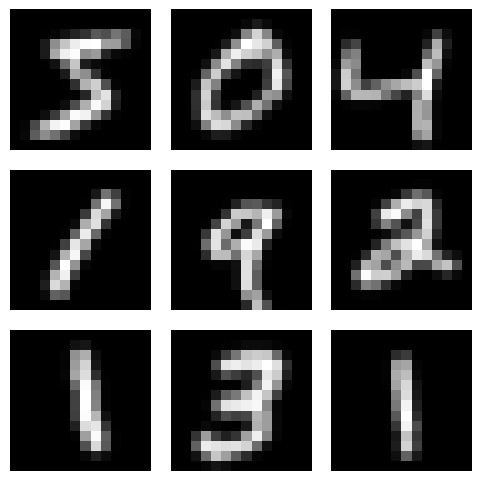

In [6]:
fig = plt.figure(figsize=(6,6))
grid = ImageGrid(fig, 111, nrows_ncols=(3,3), axes_pad=0.2)

for ax, img in zip(grid, train):
    ax.imshow(img[0].squeeze(), cmap='gray')
    ax.axis('off')

<a name="task_name_1_2"></a>
### Tokenization and Model Distribution

Autoregressive Models are used to learn the joint distribution of $p(x_{1:T})$ sequence data $x_{1:T}$ by assuming the factorization:
$$
p(x_{1:T}) = p(x_1, x_2, \dots, x_T) = \prod_{t=1}^{T} p\!\left(x_t \mid x_{1:t-1}\right)
$$

#### Patchification

However, in contrast to text, images are not naturally one-dimensional sequences but two-dimensional data points.
In practice, this is resolved by first patchifying the 2D image into a grid of patches and subsequently flattening this grid.

Below we show an example of this patchification procedure.

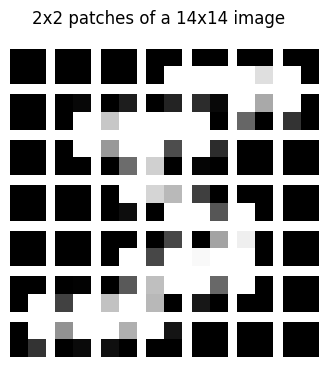

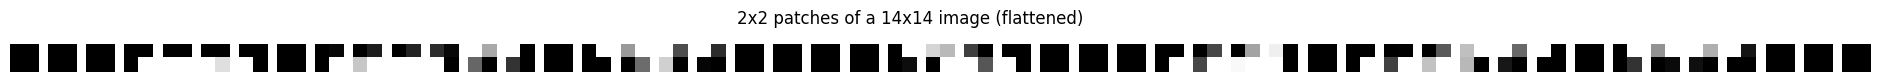

In [7]:
patches = rearrange(example_image, '1 (h p1) (w p2) -> (h w) p1 p2', p1=2, p2=2)

fig = plt.figure(figsize=(4,4))
grid = ImageGrid(fig, 111, nrows_ncols=(7,7), axes_pad=0.1)
for ax, p in zip(grid, patches):
    ax.imshow(p, cmap='gray')
    ax.axis('off')
fig.suptitle('2x2 patches of a 14x14 image')
plt.show()

fig = plt.figure(figsize=(24,1))
grid = ImageGrid(fig, 111, nrows_ncols=(1,49), axes_pad=0.1)
for ax, p in zip(grid, patches):
    ax.imshow(p, cmap='gray')
    ax.axis('off')
fig.suptitle('2x2 patches of a 14x14 image (flattened)')
plt.show()

#### Model Distribution

We need to choose a model distribution for the conditional distributions $p\!\left(x_t \mid x_{1:t-1}\right)$ that we intend to learn.  
In typical autoregressive models, sequence elements are assumed to come from a **discrete set**.  
In our case, this is:

$$
x_t \in \{0,1,\ldots,255\}^{4}.
$$

This allows us to model $p\!\left(x_t \mid x_{1:t-1}\right)$ as a categorical distribution.

#### Binarization

For the purposes of this exercise sheet, the set $\{0,\ldots,255\}^{4}$ is already too high-dimensional.  
To simplify, we **binarize** all images by thresholding at $r = 0.5$.  
This results in sequence elements of the form:

$$
x_t \in \{0,1\}^{4}.
$$

#### From Binary Vectors to Tokens

Next, we transform the binary sequence $x_{1:T}$ into a sequence of integers $d_{1:T}$, which we will refer to as our **tokens**.  
For this, each binary vector is interpreted as a binary integer code.  
For example:
$$
x_t = [1,0,0,1] \quad \Rightarrow \quad d_t = 1\times 2^0 + 0 \times 2^1 + 0 \times 2^2 + 1 \times 2^3 = 9
$$

#### Tokenization

This entire procedure of transforming input data samples into 1D sequences of discrete elements is called **tokenization**.



#### Task: Tokenizer
Implement this tokenization procedure as well as its inverse, i.e., the detokenization, in the methods `tokenize` and `detokenize` of the following skeleton code. Note and neglect that the binarization cannot be inverted.

For your convenience, we have already prepared helper functions `bin2int` and `int2bin` for the binary-to-integer transformation and its reverse. To avoid issues downstream, we recommmend, you test your implementation briefly, for instance by checking that the two functions are inverse of each other (except from the binarization)

In [8]:
class BinaryImageTokenizer():

    def __init__(self, patch_size, threshold=0.5):
        """
        patch_size: size of each patch (patch_size x patch_size)
        threshold: threshold for binarization
        """
        self.patch_size = patch_size
        self.threshold = threshold

    def bin2int(self, x):
        """
        x: input binary tensor of shape (..., patch_size**2)
        returns: decimal tensor of shape (...,)
        """
        bitvalues = 2**torch.arange(0, self.patch_size**2)
        xb = torch.matmul(x, bitvalues.to(x.device))
        return xb
    
    def int2bin(self, x):
        """
        x: input decimal tensor of shape (...,)
        returns: binary tensor of shape (..., patch_size**2)
        """
        bitvalues = 2**torch.arange(0, self.patch_size**2)
        xdec = x[..., None].bitwise_and(bitvalues.to(x.device)).ne(0).long()
        return xdec

    def tokenize(self,x):
        """
        x: input image tensor of shape (batch_size, 1, height, width)
        returns: tokenized tensor of shape (batch_size, num_patches, vocab_size)
        """
        # TODO
        x = (x > self.threshold).long()
        x = rearrange(x, 'b 1 (h p1) (w p2) -> b (h w) (p1 p2)', p1=self.patch_size, p2=self.patch_size) # (batch_size, num_patches, patch_size**2)
        x = self.bin2int(x)
        return x
    
    def detokenize(self, x):
        """
        x: input token tensor of shape (batch_size, num_patches, vocab_size)
        returns: detokenized image tensor of shape (batch_size, 1, height, width)
        """
        # TODO
        x = self.int2bin(x)
        h = w = int(np.sqrt(x.shape[1]))
        x = rearrange(x, 'b (h w) (p1 p2) -> b 1 (h p1) (w p2)', h=h, w=w, p1=self.patch_size, p2=self.patch_size)
        return x

Next, let us initialize the dataloader. We include the tokenization procedure in our [collate_function](https://docs.pytorch.org/docs/stable/data.html#working-with-collate-fn).

In [9]:
tokenizer = BinaryImageTokenizer(patch_size=2, threshold=0.5)

def collate_fn(batch):
    images, labels = zip(*batch)
    images = torch.stack(images, dim=0)
    labels = torch.tensor(labels, dtype=torch.long)

    images_tokenized = tokenizer.tokenize(images)

    return images_tokenized, labels

train_dataloader = DataLoader(train, batch_size=32, shuffle=True, drop_last=True, collate_fn=collate_fn)

Take a look what this dataloader returns as a batch. Note that the labels are the class indices (0-9) of the different digits contained in the MNIST dataset.

In [10]:
imgs, labels = next(iter(train_dataloader))
print(imgs.shape), print(labels.shape)
print(imgs)
print(labels)

torch.Size([32, 49])
torch.Size([32])
tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
tensor([3, 5, 1, 8, 0, 7, 2, 2, 3, 3, 8, 6, 4, 6, 8, 1, 1, 6, 7, 0, 7, 5, 1, 9,
        8, 0, 4, 1, 0, 7, 8, 3])


<a name="task_name_1_3"></a>
### Model Architecture
Next, we will implement our model architecture. We will build a basic decoder-only transformer. 

If you are working for the first time with the transformer architecture or need a refresher, this is a good time to take a look at the [original paper of Vaswani et al. (2017)](https://arxiv.org/pdf/1706.03762) or the excellent tutorial [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/).

#### Task: Transformer Components

Fill in the missing function bodies for the following classes. Each component corresponds to a standard operation in the Transformer architecture. Use PyTorch (`torch.nn` and `torch`) for implementation.

1. **MLP**  
   Applies two linear layers with an activation in between:  

   $$
   \text{MLP}(x) = W_2 \,\sigma(W_1 x + b_1) + b_2
   $$  

   where $\sigma$ is the GELU activation.

2. **Multi-Head Attention (MHA)**  
   - Compute queries, keys, and values:  
     $$
     Q = X W_Q, \quad K = X W_K, \quad V = X W_V
     $$
   - Split into heads, compute scaled dot-product attention:  
     $$
     \text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_h}} + \text{mask}\right)V
     $$
     Do not forget the optional attention masks here, which is crucial for causal modeling. For the mask, we use the standard, that `True` corresponds to a masked element. In this case, you can simply add 'float('-inf')' to the pre-softmax attention scores. 
   - Concatenate heads and project back:  
     $$
     \text{MHA}(X) = \bigoplus_{h=1}^H \text{Attention}(Q_h, K_h, V_h) \, W_O
     $$

3. **Transformer Block**  
    - Post-LayerNorm architecture:
        - Residual connection + LayerNorm after MHA:  
            $$
            X' = \text{LayerNorm}(X + \text{MHA}(X))
            $$
        - Residual connection + LayerNorm after MLP:  
            $$
            Y = \text{LayerNorm}(X' + \text{MLP}(X'))
            $$
    - Pre-LayerNorm architecture:
        - LayerNorm + Residual connection after MHA:  
            $$
            X' = X + \text{MHA}(\text{LayerNorm}(X))
            $$
        - LayerNorm + Residual connection after MLP:  
            $$
            Y = X' + \text{MLP}(\text{LayerNorm}(X'))
            $$
    You can choose either of the two architectures.

4. **Transformer**  
   Apply $N$ Transformer blocks sequentially:  

   $$
   Y = \text{Block}_N(\cdots \text{Block}_2(\text{Block}_1(X)) \cdots)
   $$

Implement the provided skeleton classes (`MLP`, `MultiHeadAttention`, `TransformerBlock`, `Transformer`) so they follow these formulas.


In [11]:
class MLP(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        input_dim: dimension of input features
        hidden_dim: dimension of hidden layer
        output_dim: dimension of output features
        """
        super().__init__()
        # TODO
        self.W1 = nn.Linear(input_dim, hidden_dim, bias=True)
        self.activation = nn.GELU()
        self.W2 = nn.Linear(hidden_dim, output_dim, bias=True)

    def forward(self, x):
        """
        x: input tensor of shape (..., input_dim)
        returns: output tensor of shape (..., output_dim)
        """
        # TODO
        x = self.W1(x)
        x = self.activation(x)
        x = self.W2(x)
        return x
    
class MultiHeadAttention(nn.Module):

    def __init__(self, model_dim, num_heads):
        """
        model_dim: dimension of input and output features
        num_heads: number of attention heads
        """
        super().__init__()
        # TODO

        assert model_dim % num_heads == 0, "model_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = model_dim // num_heads

        self.W_q = nn.Linear(model_dim, model_dim, bias=False)
        self.W_k = nn.Linear(model_dim, model_dim, bias=False)
        self.W_v = nn.Linear(model_dim, model_dim, bias=False)
        self.W_o = nn.Linear(model_dim, model_dim, bias=False)

    def forward(self, x, mask=None):
        """
        x: input tensor of shape (batch_size, seq_length, model_dim)
        mask: optional mask tensor of shape (batch_size, seq_length, seq_length), where True values indicates masked positions
        returns: output tensor of shape (batch_size, seq_length, model_dim)
        """
        # TODO
        batch_size, seq_length, model_dim = x.shape

        # Linear projections
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        Q = rearrange(Q, 'b s (h d) -> b h s d', h=self.num_heads)
        K = rearrange(K, 'b s (h d) -> b h s d', h=self.num_heads)
        V = rearrange(V, 'b s (h d) -> b h s d', h=self.num_heads)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.head_dim) # (batch_size, num_heads, query_seq_length, key_seq_length)
        if mask is not None:
            scores = scores.masked_fill(mask[:,None], float('-inf'))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_output = torch.matmul(attn_weights, V) # (batch_size, num_heads, query_seq_length, head_dim)

        attn_output = rearrange(attn_output, 'b h s d -> b s (h d)')
        output = self.W_o(attn_output)
        return output
    
class TransformerBlock(nn.Module):

    def __init__(self, model_dim, num_heads, hidden_dim):
        """
        model_dim: dimension of input and output features
        num_heads: number of attention heads
        hidden_dim: dimension of hidden layer in MLP
        """
        super().__init__()

        # TODO
        self.attention = MultiHeadAttention(model_dim, num_heads)
        self.norm1 = nn.LayerNorm(model_dim)
        self.mlp = MLP(model_dim, hidden_dim, model_dim)
        self.norm2 = nn.LayerNorm(model_dim)

    def forward(self, x, mask=None):
        """
        x: input tensor of shape (batch_size, seq_length, model_dim)
        mask: optional mask tensor of shape (batch_size, seq_length, seq_length), where True values indicates masked positions
        returns: output tensor of shape (batch_size, seq_length, model_dim)
        """
        # TODO
        
        # ### Pre-LN Transformer block
        # x_norm = self.norm1(x)
        # attn_output = self.attention(x_norm, mask)
        # x = x + attn_output

        # mlp_output = self.mlp(x)
        # x = x + mlp_output
        # x = self.norm2(x)
        
        ### Post-LN Transformer block
        attn_output = self.attention(x, mask)
        x = x + attn_output
        x = self.norm1(x)

        mlp_output = self.mlp(x)
        x = x + mlp_output
        x = self.norm2(x)
        

        return x

class Transformer(nn.Module):

    def __init__(self, model_dim, num_heads, feedforward_dim, num_blocks):
        """
        input_dim: dimension of input features
        model_dim: dimension of model features
        num_heads: number of attention heads
        feedforward_dim: dimension of hidden layer in MLP
        num_layers: number of transformer blocks
        num_classes: number of output classes
        """
        super().__init__()
        
        # TODO
        self.layers = nn.ModuleList([
            TransformerBlock(model_dim, num_heads, feedforward_dim) for _ in range(num_blocks)
        ])

    def forward(self, x, mask=None):
        """
        x: input tensor of shape (batch_size, seq_length, input_dim)
        mask: optional mask tensor of shape (batch_size, seq_length, seq_length), where True values indicates masked positions
        returns: output tensor of shape (batch_size, num_classes)
        """
        # TODO

        for layer in self.layers:
            x = layer(x, mask)
        return x

<a name="task_name_1_4"></a>
Next, we implement the final autoregressive decoder-only model.


#### Task: Autoregressive Transformer
Fill in the missing constructor and function bodies in `AutoregressiveTransformer`. The architecture should contain:

1. **Token Embeddings**, transforming the discrete tokens into a sequence of learnable vector representations (take a look at nn.Embedding)

2. **Positional Embeddings**. For these you can use, for instance, learnable positional embeddings. You should support a maximal sequence length of `max_seq_length`. They should be added to the embedded tokens.

3. **Transformer**, consisting of `num_blocks` blocks and `num_heads` attention heads. The hidden layer of the MLP should have the hidden dimension `feedforward_dim`. Make sure to **use a causal mask** in this component. 

4. A **LayerNorm** applied to the output of the transformer.

5. A **final linear projection** without bias term, transforming each encoded token into a logits of the next token probabilities.

Implement the functions `_generate_causal_mask`, `forward`, `sample_next_token` and `sample_sequence`.

In [12]:
class AutoregressiveTransformer(nn.Module):

    def __init__(self, vocab_size, model_dim, num_heads, feedforward_dim, num_blocks, max_seq_length):
        """
        input_dim: dimension of input features
        model_dim: dimension of model features
        num_heads: number of attention heads
        feedforward_dim: dimension of hidden layer in MLP
        num_layers: number of transformer blocks
        num_classes: number of output classes
        max_seq_length: maximum sequence length
        """
        super().__init__()
        self.max_seq_length = max_seq_length
        self.token_embedding = nn.Embedding(vocab_size, model_dim)
        self.pos_embedding = nn.Embedding(max_seq_length, model_dim)
        self.transformer = Transformer(model_dim, num_heads, feedforward_dim, num_blocks)
        self.ln = nn.LayerNorm(model_dim)
        self.to_logits = nn.Linear(model_dim, vocab_size, bias=False)

    def _generate_causal_mask(self, seq_length):
        """
        seq_length: length of the sequence
        returns: causal mask tensor of shape (seq_length, seq_length)
        """
        mask = torch.triu(torch.ones(seq_length, seq_length), diagonal=1).bool()
        return mask

    def forward(self, x):
        """
        x: input tensor of shape (batch_size, seq_length)
        returns: output tensor containing logits of shape (batch_size, seq_length, vocab_size)
        """
        batch_size, seq_length = x.shape
        positions = torch.arange(0, seq_length).unsqueeze(0).expand(batch_size, seq_length).to(x.device)

        x = self.token_embedding(x)
        x = x + self.pos_embedding(positions)

        mask = self._generate_causal_mask(seq_length).to(x.device)
        mask = mask.unsqueeze(0).expand(batch_size, -1, -1)

        x = self.transformer(x, mask)
        x = self.ln(x)

        x = self.to_logits(x)

        return x
    
    @torch.no_grad()
    def sample_next_token(self, x, temperature=1.0):
        """
        x: input tensor of shape (batch_size, seq_length)
        returns: output tensor containing logits of shape (batch_size,)
        """
        logits = self.forward(x) # (batch_size, seq_length, vocab_size)
        probs = F.softmax(logits[:, -1, :]/temperature, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)[:,0] # (batch_size,)
        return next_token
    
    @torch.no_grad()
    def sample_sequence(self, x, seq_length, temperature=1.0):
        """
        x: input tensor of shape (batch_size, initial_seq_length)
        seq_length: number of tokens to generate
        returns: output tensor containing generated sequence of shape (batch_size, initial_seq_length + seq_length)
        """
        for _ in range(seq_length):
            next_token = self.sample_next_token(x, temperature=temperature)
            x = torch.cat([x, next_token.unsqueeze(-1)], dim=-1)
        return x

<a name="task_name_1_5"></a>
### Autoregressive Training

We are now ready to assemble all components and train our autoregressive transformer!

Now, we initialize and train our model.

In [13]:
model = AutoregressiveTransformer(TOTAL_VOCAB_SIZE, model_dim=128, num_heads=4, feedforward_dim=256, num_blocks=6, max_seq_length=100)

In [14]:
num_epochs = 3

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
losses = []

for epoch in range(num_epochs):
    avg_loss = 0
    for tokenized_images, labels in tqdm(train_dataloader):
        tokenized_images = tokenized_images + NUM_CLASSES
        x = torch.concat([labels[:,None], tokenized_images], dim=1)

        logits = model.forward(x)
        loss = nn.CrossEntropyLoss()(logits[:,:-1].reshape(-1, TOTAL_VOCAB_SIZE), x[:,1:].reshape(-1))

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

100%|██████████| 1875/1875 [02:13<00:00, 14.02it/s]


Epoch 1/3, Loss: 0.6258


100%|██████████| 1875/1875 [02:16<00:00, 13.72it/s]


Epoch 2/3, Loss: 0.4988


100%|██████████| 1875/1875 [02:23<00:00, 13.05it/s]

Epoch 3/3, Loss: 0.5534


Finally, let's generate an image conditioned on a specific class:

In [17]:
condition = 0
sampled = model.sample_sequence(x=torch.tensor([[condition]], dtype=torch.long), seq_length=49, temperature=1.0)
sampled_detokenized = tokenizer.detokenize(sampled[:,1:] - NUM_CLASSES)

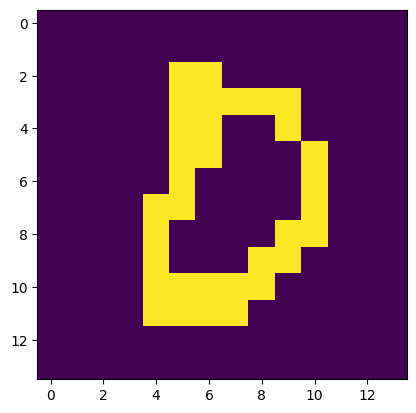

In [18]:
plt.imshow(sampled_detokenized[0][0])

#### Transformer Visualization

- https://bbycroft.net/llm

- https://poloclub.github.io/transformer-explainer/



<a name="task_name_1_6"></a>

## Open Questions
  - Are there more effective ways to tokenize images for autoregressive modeling?
  - What’s the trade-off between patch size (e.g., 2×2 vs 4×4) and sequence length on training stability, context use, and generation quality?
  - For a fixed FLOPs budget, is it better to increase depth (blocks) or width (d_model) for this task? Where’s the break-even?
  - How does the number of heads vs head dimension affect attention entropy and long-range dependencies across image patches?
  - Does a final LayerNorm and pre-norm blocks measurably improve optimization speed or calibration here?
  - With the same model, how do PyTorch SDPA, FlashAttention, and block-sparse/dilated attention compare on **prefill throughput** and **token-by-token latency**?
  - How do different sampling strategies (e.g., temperature, top-k, nucleus) affect the diversity and quality of generated samples?
  - Beyond visual inspection, which metrics best reflect improvements?